In [1]:
import numpy as np
import matplotlib.pyplot as plt

x=np.array([5,1,2,1])
y=np.array([25,5,7,8])
x0=2
tau=0.4

In [3]:
X=np.column_stack((np.ones(len(x)),x))
weights =np.exp(-((x-x0)**2)/(2* tau ** 2))
W=np.diag(weights)
X_T_W=np.dot(X.T,W)
X_T_W_X_inv= np.linalg.pinv(np.dot(X_T_W,X))

beta_hat=np.dot(np.dot(X_T_W_X_inv,X_T_W),y)
print("Estimated Coefficients(beta):",beta_hat)

Estimated Coefficients(beta): [6.  0.5]


In [4]:
y0=np.dot(np.array([1,x0]),beta_hat)
print(f"Predicted value at x0 ={x0}: {y0}")

Predicted value at x0 =2: 7.000000000040318


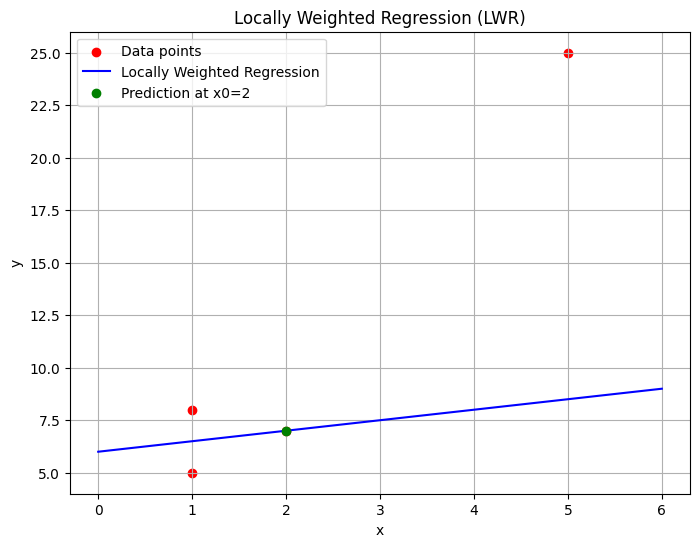

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red', label='Data points')
x_range = np.linspace(min(x) - 1, max(x) + 1, 100)
y_range = np.array([np.dot(np.array([1, xi]), beta_hat) for xi in x_range])
plt.plot(x_range, y_range, color='blue', label='Locally Weighted Regression')
plt.scatter(x0, y0, color='green', label=f'Prediction at x0={x0}', zorder=3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Locally Weighted Regression (LWR)')
plt.legend()
plt.grid(True)
plt.show()